# Raw HFR radial data summary and quick visualization of Quality Control impact on the data 

In [14]:
import warnings
get_ipython().run_line_magic('run', '"/media/nbourg/One Touch/PhD/Separation_HFR_EAC/toolbox.ipynb"')
warnings.filterwarnings('ignore')

------

## HFR Technical Informations

From thredds, COFFS Harbour radials are already gridded on a cartesian grid of resolution 1.5km. 

| Name | Type | Longitude | Latitude | Angular Resolution | Range Resolution |
| --- | --- | --- | --- | --- | --- |
| RHED (NEWC) | CODAR | 151.72°E | 33.01°S |2.0 deg | 13.5913 km |
| SEAL (NEWC) | CODAR | 152.53°E | 32.44°S | 2.0 deg | 13.5913 km | 
| RRK (COFFS) | WERA | 153.23°E | 29.98°S | / | / |
| NNB (COFFS) | WERA | 153.01°E | 30.62°S | / | / |


Newcastle cartesian grid (from IMOS example) : resolution ~6km
Diff(lon) = 0.0653°, Diff(lat)=0.0541° 

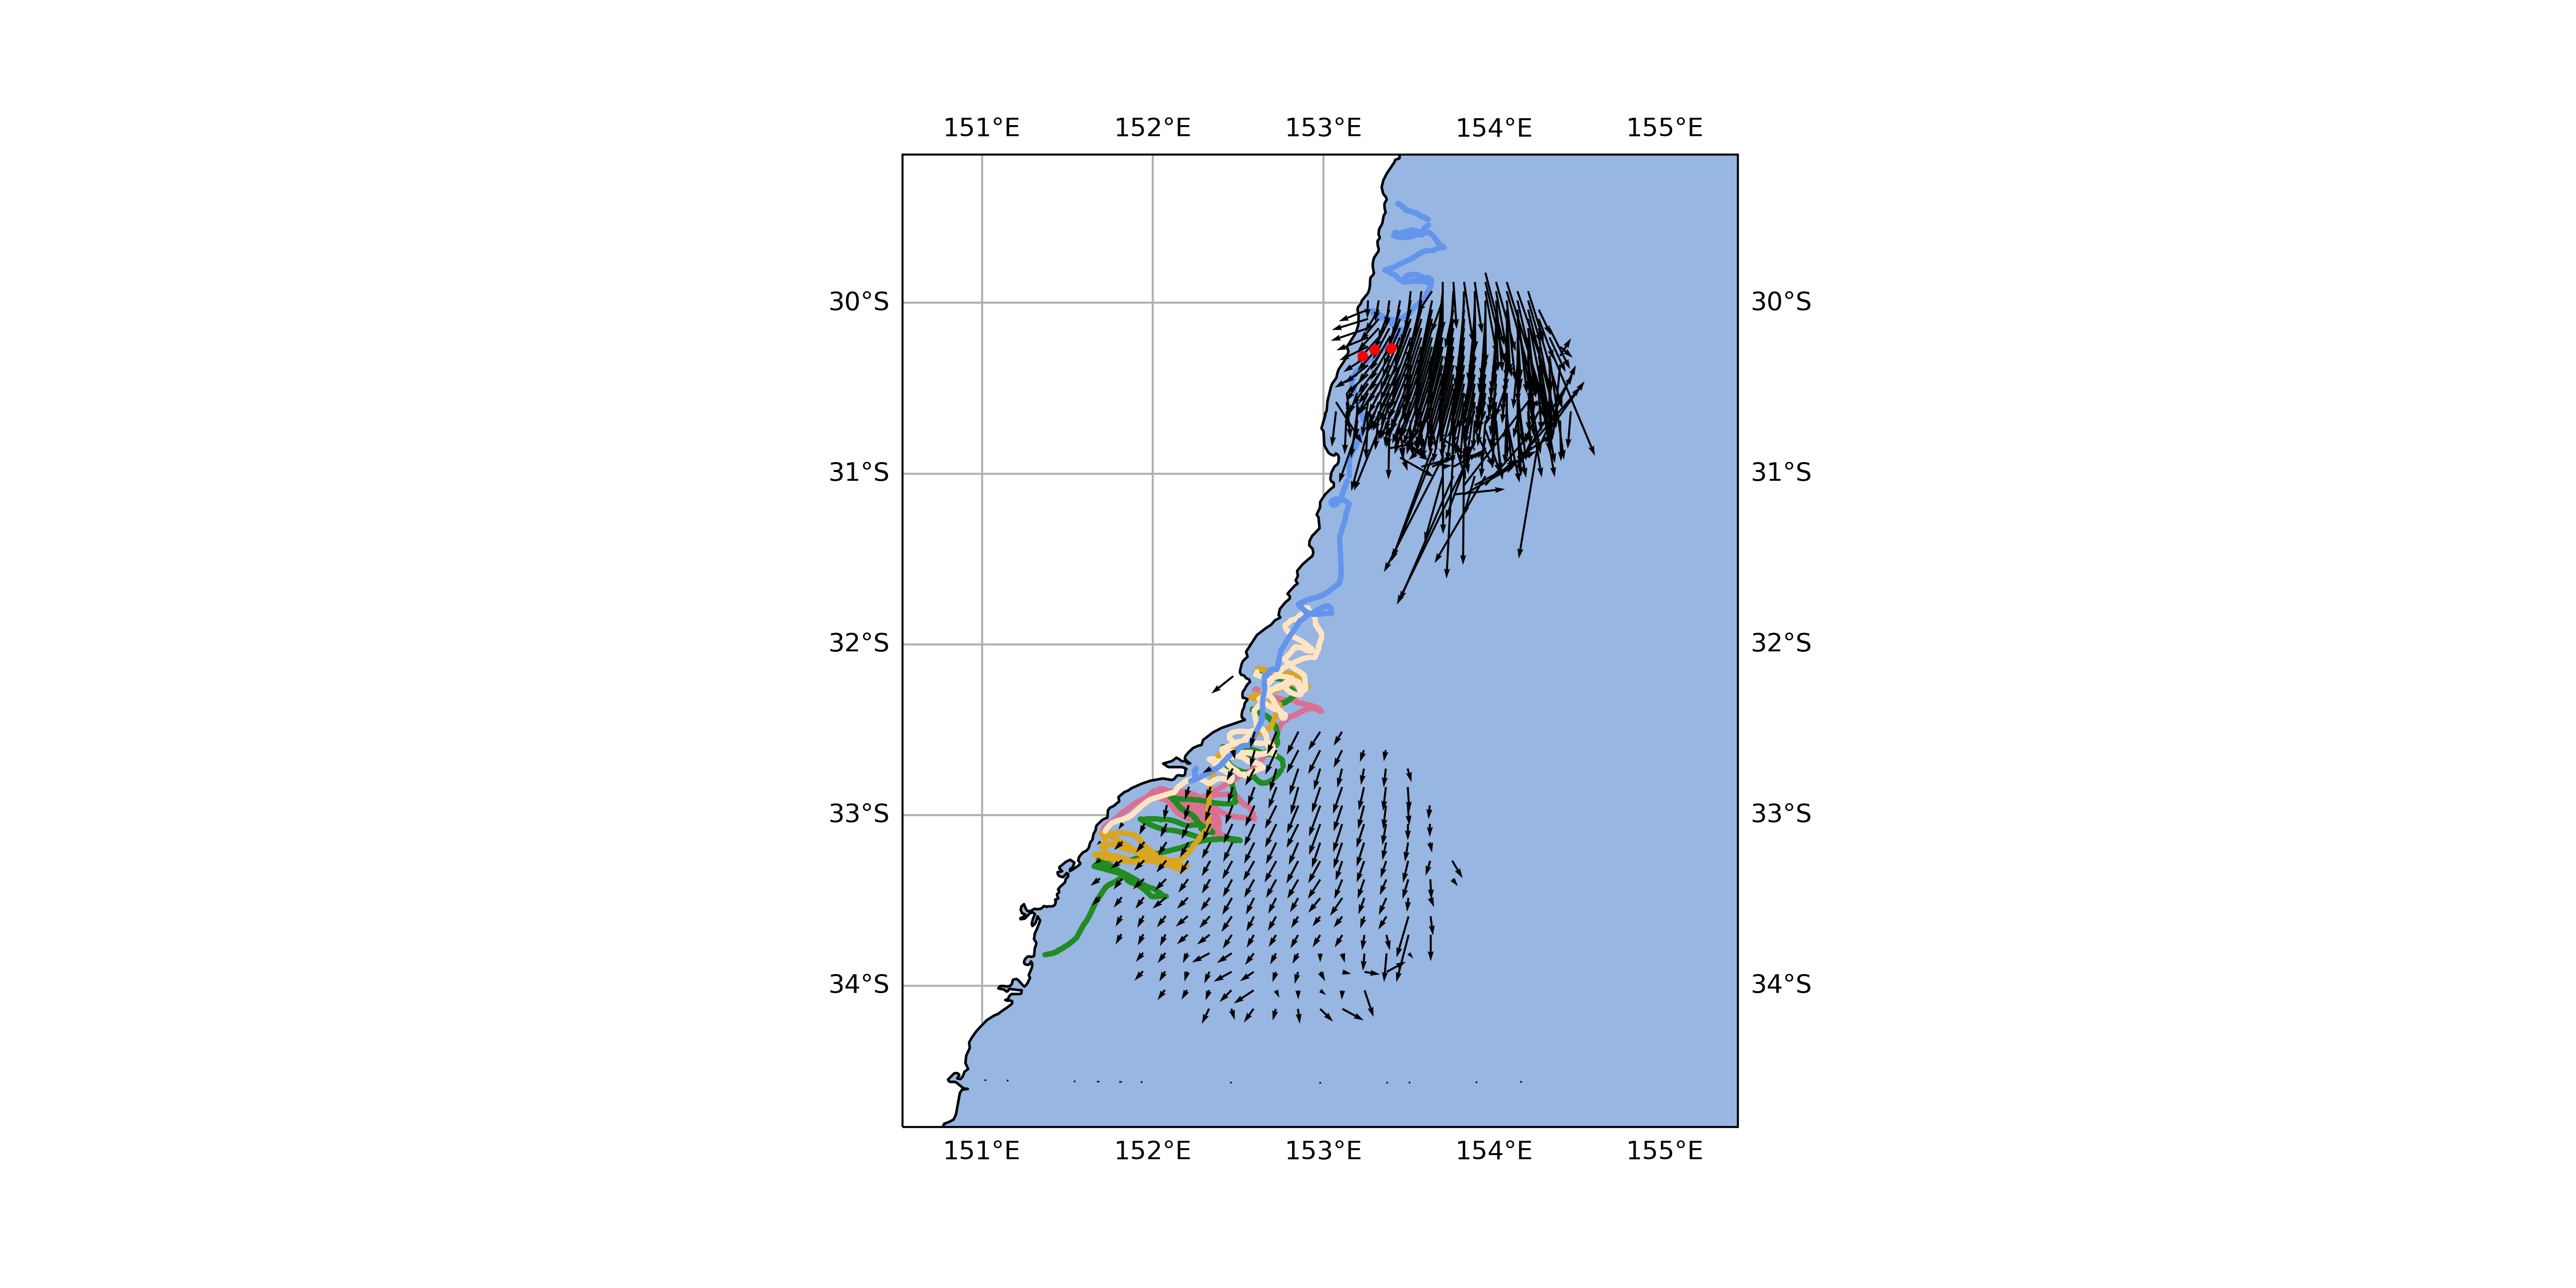

---

## Raw data availability

In [171]:
import numpy as np
import matplotlib.pyplot as plt 
import xarray as xr
import pandas as pd
import glob 

path = '/media/nbourg/One Touch/PhD/Separation_HFR_EAC/Data/HFR/Radials/'
rhed = xr.open_mfdataset(path+'RHED'+'/Gridded/*.nc')
seal = xr.open_mfdataset(path+'SEAL'+'/Gridded/*.nc')

rhed_qc=np.concatenate([xr.open_dataset(f)['vr'].values for f in glob.glob(path+'RHED'+'/QCed/RHED_Y*_QC.nc')],axis=0)
seal_qc=np.concatenate([xr.open_dataset(f)['vr'].values for f in glob.glob(path+'SEAL'+'/QCed/SEAL_Y*_QC.nc')],axis=0)

rhed_daily = xr.open_dataset(path+'RHED'+'/QCed/RHED_daily_Y2019_M07_Y2021_M12.nc')
seal_daily = xr.open_dataset(path+'SEAL'+'/QCed/SEAL_daily_Y2019_M07_Y2021_M12.nc')


rrk_qc=np.concatenate([xr.open_dataset(f)['vr'].values for f in glob.glob(path+'RRK'+'/QCed/RRK_Y*_QC.nc')],axis=0)
nnb_qc=np.concatenate([xr.open_dataset(f)['vr'].values for f in glob.glob(path+'NNB'+'/QCed/NNB_Y*_QC.nc')],axis=0)

rrk_daily = xr.open_dataset(path+'RRK'+'/QCed/RRK_daily_Y2019_M07_Y2021_M12.nc')
nnb_daily = xr.open_dataset(path+'NNB'+'/QCed/NNB_daily_Y2019_M07_Y2021_M12.nc')


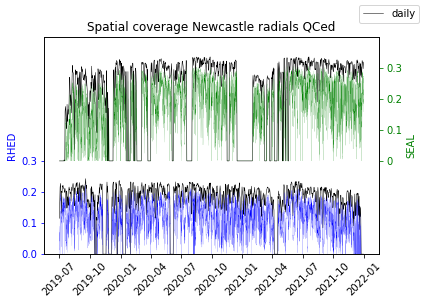

In [170]:
fig,ax=plt.subplots()
ax.title.set_text('Spatial coverage Newcastle radials QCed')

ax.plot(rhed_daily['time'].values,
        get_spatial_coverage(rhed_daily['vr'].values),
        linewidth=0.5,
        color='k',
       zorder=0,label='daily')

ax.plot(rhed['time'].values,
        get_spatial_coverage(rhed_qc),
        linewidth=0.1,
        color='blue',
       zorder=3)

ax2=ax.twinx()
ax2.plot(seal['time'].values,0.3+get_spatial_coverage(seal_qc),linewidth=0.1,color='green')

ax2.plot(seal_daily['time'].values,
        0.3+get_spatial_coverage(seal_daily['vr'].values),
        linewidth=0.5,
        color='k',
       zorder=0)

ax.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='x', rotation=45)

ax.set_yticks([0,0.1,0.2,0.3])
ax2.set_yticks([0.3,0.4,0.5,0.6])

ax2.set_yticklabels(['0','0.1','0.2','0.3'])
ax2.tick_params(axis='y', colors='green')
ax.tick_params(axis='y', colors='blue')
ax.set_ylabel('RHED')
ax2.set_ylabel('SEAL')

ax.set_ylim(0,0.7)
ax2.set_ylim(0,0.7)

ax.yaxis.label.set_color('blue')
ax2.yaxis.label.set_color('green')

fig.legend()

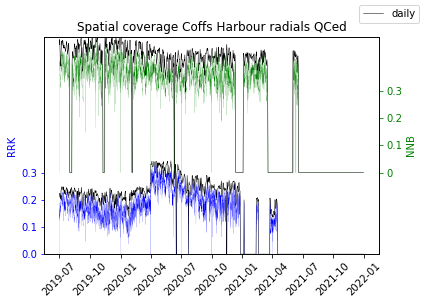

In [174]:
fig,ax=plt.subplots()
ax.title.set_text('Spatial coverage Coffs Harbour radials QCed')

ax.plot(rrk_daily['time'].values,
        get_spatial_coverage(rrk_daily['vr'].values),
        linewidth=0.5,
        color='k',
       zorder=0,label='daily')

ax.plot(seal['time'].values,
        get_spatial_coverage(rrk_qc),
        linewidth=0.1,
        color='blue',
       zorder=3)

ax2=ax.twinx()
ax2.plot(seal['time'].values,0.3+get_spatial_coverage(nnb_qc),linewidth=0.1,color='green')

ax2.plot(nnb_daily['time'].values,
        0.3+get_spatial_coverage(nnb_daily['vr'].values),
        linewidth=0.5,
        color='k',
       zorder=0)

ax.tick_params(axis='x', rotation=45)
ax2.tick_params(axis='x', rotation=45)

ax.set_yticks([0,0.1,0.2,0.3])
ax2.set_yticks([0.3,0.4,0.5,0.6])

ax2.set_yticklabels(['0','0.1','0.2','0.3'])
ax2.tick_params(axis='y', colors='green')
ax.tick_params(axis='y', colors='blue')
ax.set_ylabel('RRK')
ax2.set_ylabel('NNB')

ax.set_ylim(0,0.8)
ax2.set_ylim(0,0.8)

ax.yaxis.label.set_color('blue')
ax2.yaxis.label.set_color('green')

fig.legend()

# Some examples of before and after QC

Text(0.5, 0.98, 'STD Radial Velocity ')

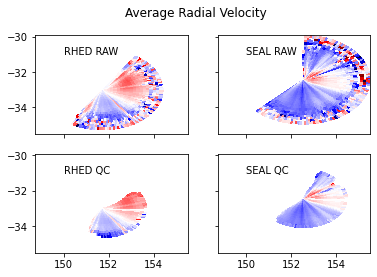

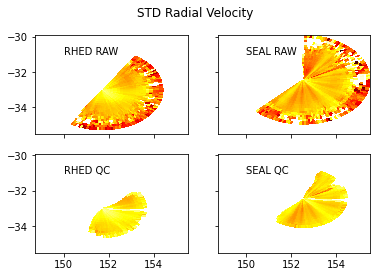

In [157]:
fig,axs=plt.subplots(ncols=2,nrows=2,sharex=True,sharey=True)
axs[0,0].pcolor(rhed['lon'].values,rhed['lat'].values,np.nanmean(rhed['vr'].values,axis=0),vmin=-1,vmax=1,cmap='seismic')
axs[1,0].pcolor(rhed['lon'].values,rhed['lat'].values,np.nanmean(rhed_qc,axis=0),vmin=-1,vmax=1,cmap='seismic')

axs[0,1].pcolor(seal['lon'].values,seal['lat'].values,np.nanmean(seal['vr'].values,axis=0),vmin=-1,vmax=1,cmap='seismic')
axs[1,1].pcolor(seal['lon'].values,seal['lat'].values,np.nanmean(seal_qc,axis=0),vmin=-1,vmax=1,cmap='seismic')

axs[0,0].text(150,-31,'RHED RAW')
axs[1,0].text(150,-31,'RHED QC')

axs[0,1].text(150,-31,'SEAL RAW')
axs[1,1].text(150,-31,'SEAL QC')
fig.suptitle('Average Radial Velocity ')

fig,axs=plt.subplots(ncols=2,nrows=2,sharex=True,sharey=True)
axs[0,0].pcolor(rhed['lon'].values,rhed['lat'].values,np.nanstd(rhed['vr'].values,axis=0),vmin=0,vmax=1,cmap='hot_r')
axs[1,0].pcolor(rhed['lon'].values,rhed['lat'].values,np.nanstd(rhed_qc,axis=0),vmin=0,vmax=1,cmap='hot_r')

axs[0,1].pcolor(seal['lon'].values,seal['lat'].values,np.nanstd(seal['vr'].values,axis=0),vmin=0,vmax=1,cmap='hot_r')
axs[1,1].pcolor(seal['lon'].values,seal['lat'].values,np.nanstd(seal_qc,axis=0),vmin=0,vmax=1,cmap='hot_r')

axs[0,0].text(150,-31,'RHED RAW')
axs[1,0].text(150,-31,'RHED QC')

axs[0,1].text(150,-31,'SEAL RAW')
axs[1,1].text(150,-31,'SEAL QC')
fig.suptitle('STD Radial Velocity ')


Text(1000, -1, 'Linear interpolation')

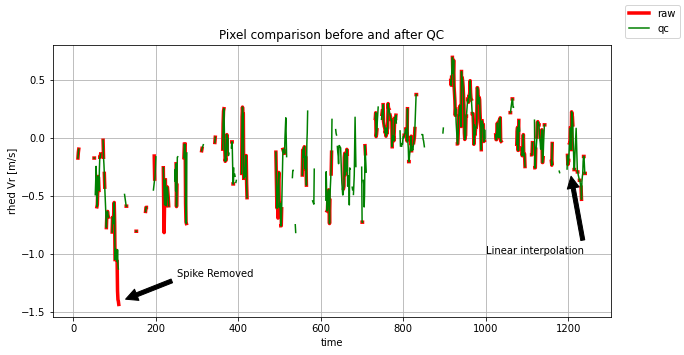

In [154]:
fig,ax=plt.subplots(figsize=(10,5))
ax.plot(rhed['vr'][5250:6500,140,6],linewidth=3.5,label='raw',color='r')
ax.plot(rhed_qc[5250:6500,140,6],linewidth=1.5,label='qc',color='green')
fig.legend()
ax.set_xlabel('time')
ax.set_ylabel('rhed Vr [m/s]')
ax.grid()
ax.title.set_text('Pixel comparison before and after QC')
ax.annotate('Spike Removed', xy=(120, -1.4), xytext=(250, -1.2),
            arrowprops=dict(facecolor='black', shrink=0.05))
ax.annotate('Linear interpolation', xy=(1205, -.3), xytext=(1000, -1),
            arrowprops=dict(facecolor='black', shrink=0.05))


---

## Low pass filter

We use pl66tn.m lowpass filter before daily averaging to filter out all frequencies higher than 38h.

Woods et al., 2016 use 38hrs,  

Schaeffer & Gramoullé 2017 use PL64: "Tidal and inertial fluctuations were filtered out using the PL-64 low pass filter (half amplitude 33 hour, half power 38 hour, Rosenfeld [1983])" 

PL66 is same as PL64 but "better" because it removes the 4th cut point at 0 at 2*T.  

How is PL66 handling NaNs: If the timeseries is cut by NaNs it will take part by part and execute the lowpass filter on different pieces of the timeseries. If the series is long enough it will do the whole cutoff frequency thing, if not it will apply a moving average.

It does not change much to the data but it is more correct

Example belox on a pixel of daily averaged velocity, not lowpassed (blue) and lowpassed (red).

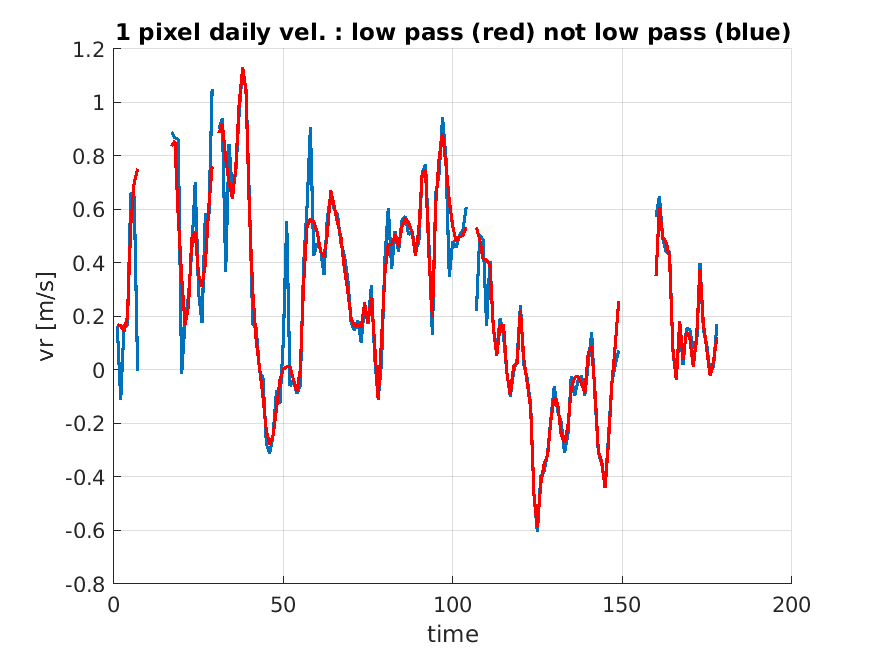